In [3]:
from google.colab import files

print("Clique no botão abaixo para selecionar o arquivo 'Bank_Customer_Churn_Prediction.csv'do computador ")
arquivos = files.upload()

Clique no botão abaixo para selecionar o arquivo 'Bank_Customer_Churn_Prediction.csv'do computador 


Saving Bank_Customer_Churn_Prediction.csv to Bank_Customer_Churn_Prediction.csv


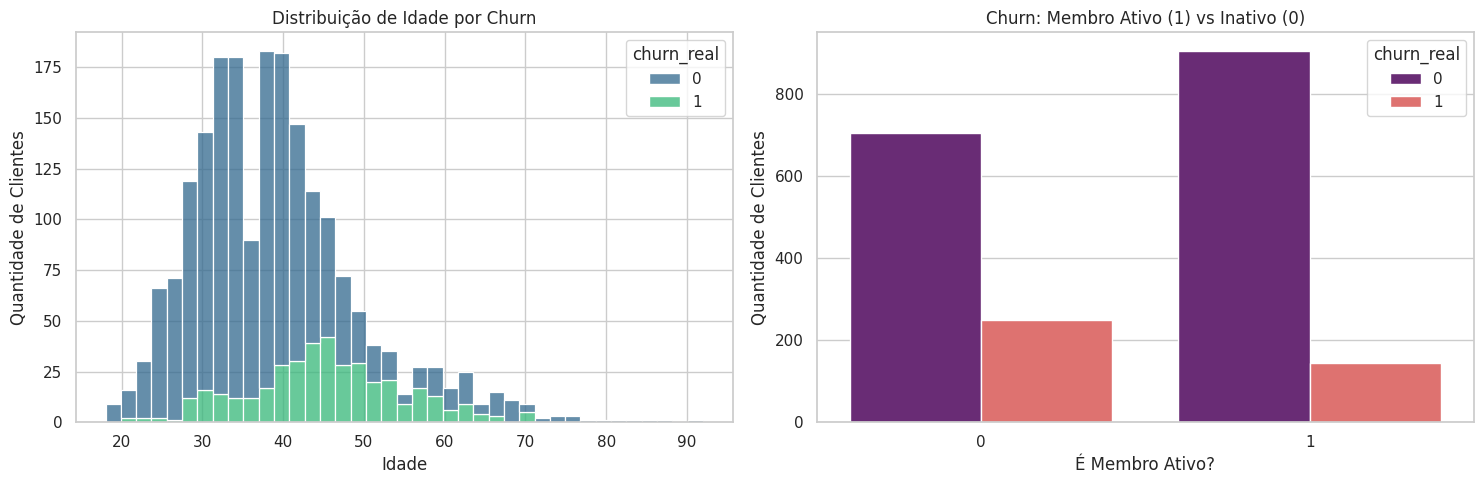

### Dados carregados e gráficos gerados com sucesso! ###


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o arquivo
df_clean = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

# Garantir que os dados são lidos como números inteiros para os gráficos
df_clean['membro_ativo'] = df_clean['membro_ativo'].astype(int)
df_clean['churn_real'] = df_clean['churn_real'].astype(int)
df_clean['idade'] = df_clean['idade'].astype(int)

# 2. Configurando o estilo visual dos gráficos originais
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Churn por Faixa Etária
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='idade', hue='churn_real', multiple="stack", palette='viridis')
plt.title('Distribuição de Idade por Churn')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Clientes')

# Gráfico 2: Churn por Status de Membro Ativo (Agora vai preencher!)
plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='membro_ativo', hue='churn_real', palette='magma')
plt.title('Churn: Membro Ativo (1) vs Inativo (0)')
plt.xlabel('É Membro Ativo?')
plt.ylabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

print("### Dados carregados e gráficos gerados com sucesso! ###")


### RELATÓRIO TÉCNICO DE CLASSIFICAÇÃO (F1-SCORE) ###
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



<Figure size 600x600 with 0 Axes>

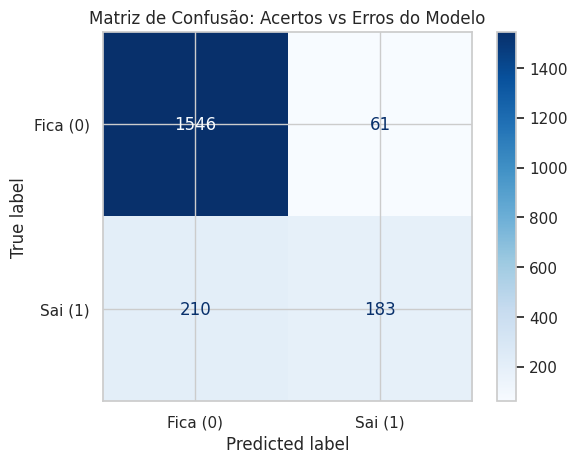

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Exibir o Relatório Técnico (onde o F1-Score aparece)
print("\n### RELATÓRIO TÉCNICO DE CLASSIFICAÇÃO (F1-SCORE) ###")
print(classification_report(df_clean['churn_real'], df_clean['previsao_modelo']))

# 2. Gerar a Matriz de Confusão Visual
plt.figure(figsize=(6, 6))
cm = confusion_matrix(df_clean['churn_real'], df_clean['previsao_modelo'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fica (0)', 'Sai (1)'])

disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão: Acertos vs Erros do Modelo')
plt.show()